In [1]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt
from typing import cast
import numpy as np

In [2]:
def read_losses(obj, lr):
    res_path = (
        data_root
        / "results"
        / "sgd_models_dehydration"
        / "scalar_regression"
        / obj
        / f"{lr}lr_48epoch_512batch"
        / "spheres_512emb_6block_4head_10tet"
    )
    try:
        train_losses = pd.read_csv(
            res_path / "train_losses.csv",
            header=None,
            index_col=0,
        ).squeeze("columns")
        test_losses = pd.read_csv(
            res_path / "test_losses.csv",
            header=None,
            index_col=0,
        ).squeeze("columns")

        train_losses = cast(pd.Series, train_losses)
        test_losses = cast(pd.Series, test_losses)

        train_losses.index.name = None
        test_losses.index.name = None

        return train_losses, test_losses
    except FileNotFoundError:
        return None, None

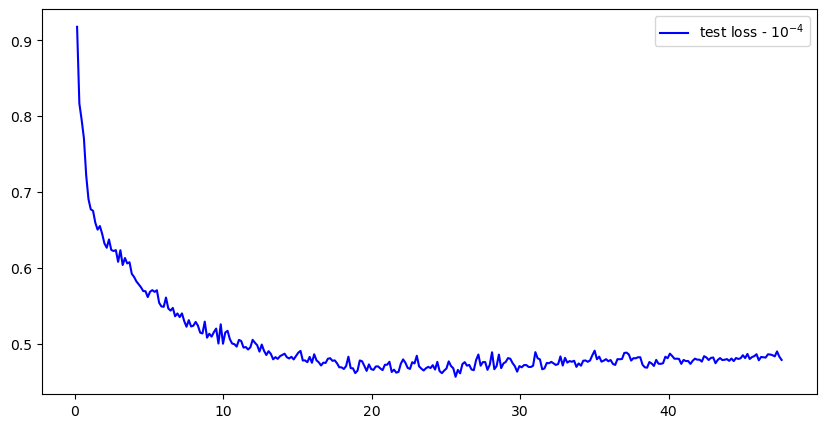

In [9]:
obj_func = "count_5_deg"


def plot(train_losses, test_losses, label, ax, color):
    if train_losses is None or test_losses is None:
        return

    # ax.plot(
    #     train_losses.index * 512 / 1e6,
    #     train_losses,
    #     ls="--",
    #     color=color,
    #     label=f"train loss - {label}",
    # )
    ax.plot(
        test_losses.index * 512 / 1e6,
        test_losses,
        color=color,
        label=f"test loss - {label}",
    )


fig, ax = plt.subplots(figsize=(10, 5))

train_losses_xlow, test_losses_xlow = read_losses(obj_func, 1e-5)
train_losses_low, test_losses_low = read_losses(obj_func, 3e-5)
train_losses_med, test_losses_med = read_losses(obj_func, 1e-4)
train_losses_high, test_losses_high = read_losses(obj_func, 3e-4)
train_losses_xhigh, test_losses_xhigh = read_losses(obj_func, 1e-3)

# plot(train_losses_xlow, test_losses_xlow, "$10^{-5}$", ax, "lime")
# plot(train_losses_low, test_losses_low, "$3 \\times 10^{-5}$", ax, "green")
plot(train_losses_med, test_losses_med, "$10^{-4}$", ax, "blue")
# plot(train_losses_high, test_losses_high, "$3 \\times 10^{-4}$", ax, "orange")
# plot(train_losses_xhigh, test_losses_xhigh, "$10^{-3}$", ax, "red")

# ax.set_xlim(0, 16)

plt.legend()
# plt.loglog()

plt.show()